# Graphs for Demand Exercise

NOTE: The scripts below requires python and an installation of the pybalmorel module. This module is very new, so be critical. Feel free to post issues [here](https://github.com/Mathias157/pybalmorel/issues)

**Installation:**

Open a terminal, activate your virtual environment and write:

`pip install pybalmorel`

## Loading Results

In [ ]:
!pip install pybalmorel

In [5]:
import pybalmorel 
import matplotlib.pyplot as plt

In [6]:
from pathlib import Path
from pybalmorel import MainResults
from pybalmorel.formatting import balmorel_colours

results_path = Path.cwd() / "0_results_for_python_noDECOM"

print(results_path)

res = MainResults(
    files=["1.gdx", "2.gdx", "3.gdx", "4.gdx", "Base.gdx", "2025.gdx"],
    paths=str(results_path)
)

c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM
Loading c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM\1.gdx
Loading c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM\2.gdx
Loading c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM\3.gdx
Loading c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM\4.gdx
Loading c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM\Base.gdx
Loading c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM\2025.gdx


In [46]:
# Human-readable x-axis labels
SCENARIO_LABELS = {
    '1':      'S1 (HT-LN)',
    '2': 'S2 (HT-HN)',
    '3': 'S3 (LT-LN)',
    '4':       'S4 (LT-HN)',
}

def apply_scenario_labels(ax):
    """Replace raw scenario names on x-axis with human-readable labels."""
    ax.set_xticklabels([SCENARIO_LABELS.get(t.get_text(), t.get_text())
                        for t in ax.get_xticklabels()])
    ax.set_xlabel('Scenarios')

## Plotting CO2 emissions Validation

Raw result columns: ['Scenario', 'Y', 'C', 'RRR', 'AAA', 'G', 'FFF', 'TECH_TYPE', 'UNITS', 'Value']
Unique values in C: ['DENMARK', 'NORWAY']


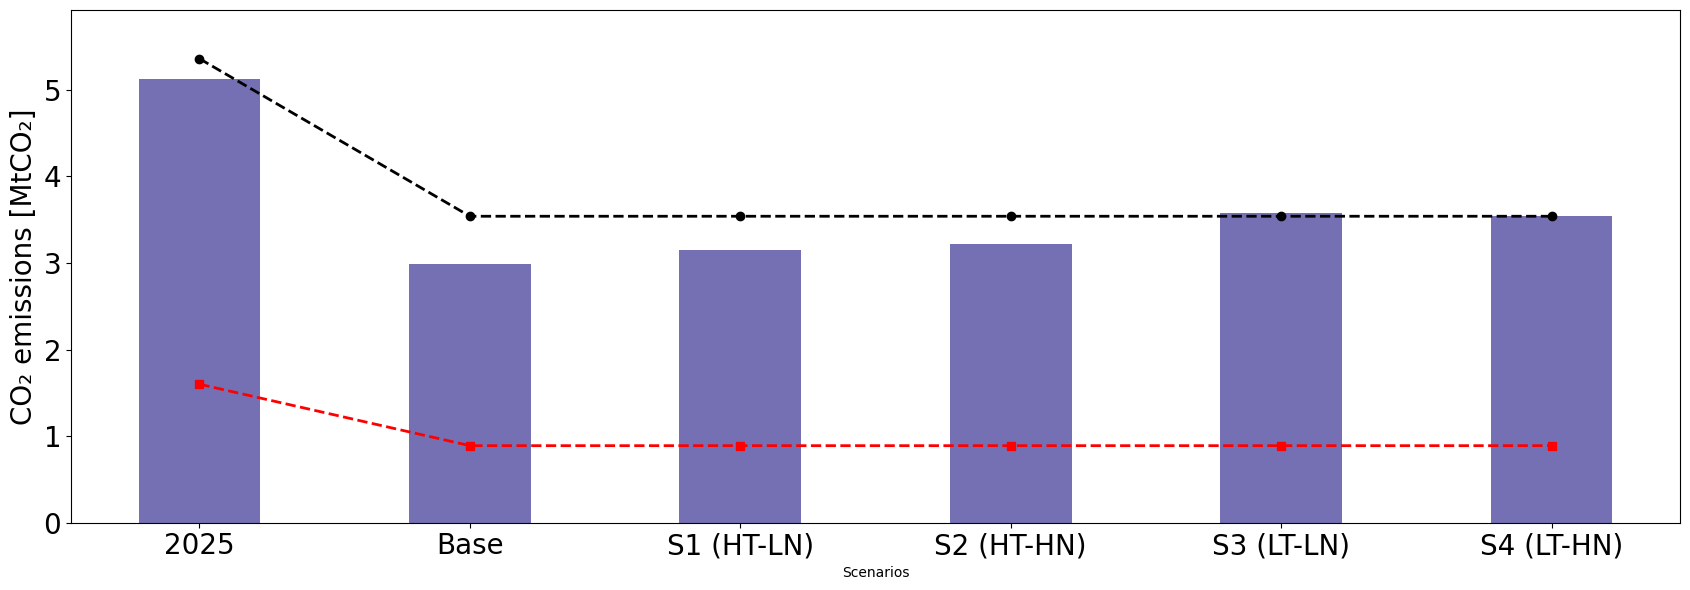

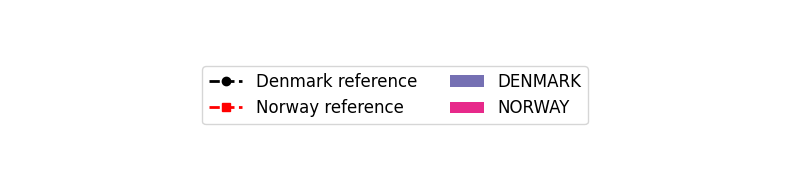

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

obj_emi = res.get_result('EMI_YCRAG')

print('Raw result columns:', obj_emi.columns.tolist())
print('Unique values in C:', sorted(obj_emi['C'].dropna().unique().tolist()))

# Aggregate by scenario and country/region
obj_emi = obj_emi.pivot_table(
    index='Scenario',
    columns='C',
    values='Value',
    aggfunc='sum',
    fill_value=0
)

# Convert from kton to Mt
obj_emi_mton = obj_emi / 1000.0

# Reorder scenarios
scenario_order = ['2025', 'Base', '1', '2', '3', '4']
obj_emi_mton = obj_emi_mton.reindex(scenario_order).fillna(0)

# Reference values in MtCO2
denmark_ref = {
    '2025': 5.36,
    'Base': 3.54,
    '1': 3.54,
    '2': 3.54,
    '3': 3.54,
    '4': 3.54
}

norway_ref = {
    '2025': 1.60,
    'Base': 0.89,
    '1': 0.89,
    '2': 0.89,
    '3': 0.89,
    '4': 0.89
}

den_series = pd.Series(denmark_ref).reindex(obj_emi_mton.index)
nor_series = pd.Series(norway_ref).reindex(obj_emi_mton.index)

# Colors for the stacked bars
cmap = plt.colormaps['Dark2']
color_list = cmap.colors[2:2 + len(obj_emi_mton.columns)]

# Plot stacked bars
ax = obj_emi_mton.plot(
    kind='bar',
    stacked=True,
    grid=False,
    rot=0,
    figsize=(17, 6),
    width=0.45,
    color=color_list,
    legend=False
)

apply_scenario_labels(ax)

# Titles and labels
ax.set_ylabel('CO₂ emissions [MtCO₂]', fontsize=20)

# Axis font sizes
ax.tick_params(axis='both', labelsize=20)

# Add some space above the highest value
ax.set_ylim(top=ax.get_ylim()[1] * 1.10)

# Overlay reference lines
x = np.arange(len(obj_emi_mton.index))

ax.plot(
    x,
    den_series.values,
    marker='o',
    linestyle='--',
    color='black',
    linewidth=2,
    label='Denmark reference'
)

ax.plot(
    x,
    nor_series.values,
    marker='s',
    linestyle='--',
    color='red',
    linewidth=2,
    label='Norway reference'
)

plt.tight_layout()
plt.show()

# Independent legend
handles, labels = ax.get_legend_handles_labels()

fig_leg, ax_leg = plt.subplots(figsize=(8, 2))
ax_leg.axis('off')

ax_leg.legend(
    handles,
    labels,
    ncol=2,
    frameon=True,
    fontsize=12,
    loc='center'
)

plt.tight_layout()
plt.show()

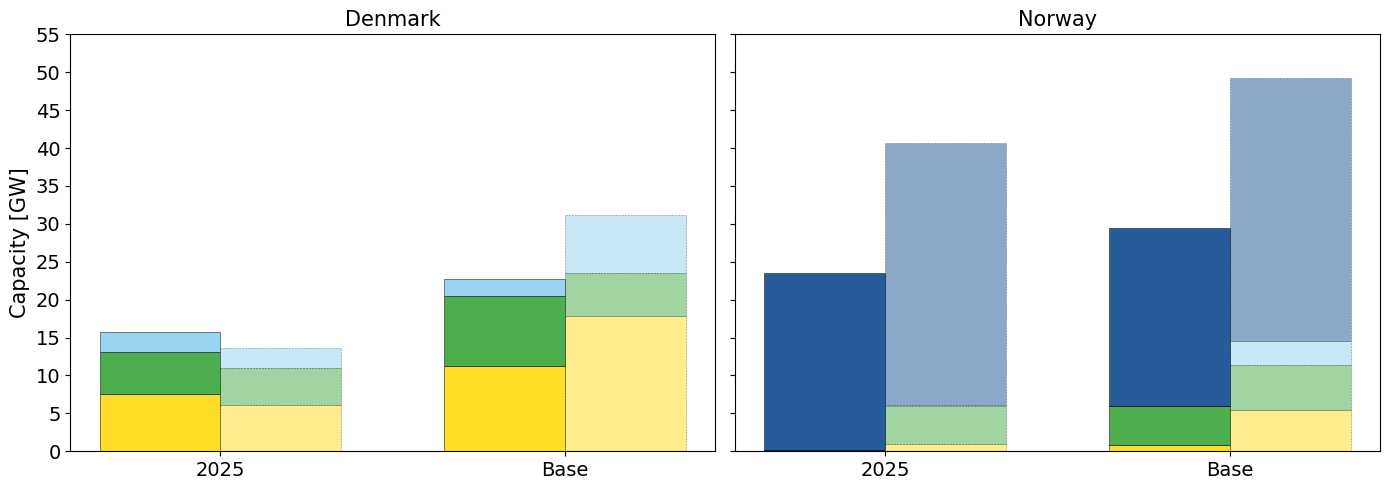

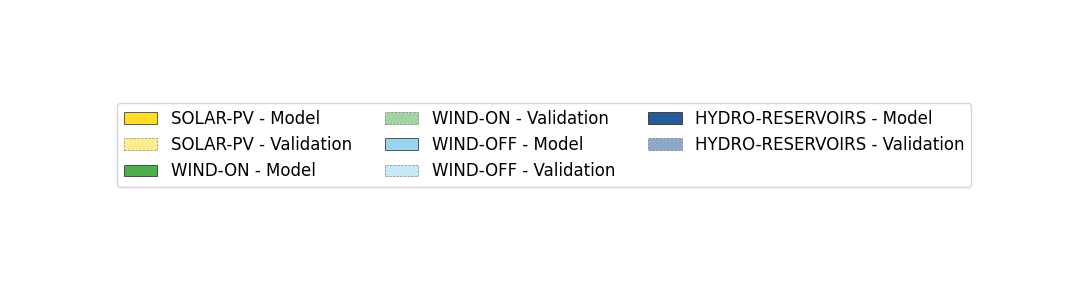

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# HARDCODED VALIDATION DATA FROM TABLE
# ============================================================
validation_data = {
    ('DENMARK', '2025'): {
        'SOLAR-PV': 6.05, 'WIND-ON': 5.0, 'WIND-OFF': 2.55, 'HYDRO-RESERVOIRS': 0
    },
    ('DENMARK', '2030'): {
        'SOLAR-PV': 17.79, 'WIND-ON': 5.7, 'WIND-OFF': 7.71, 'HYDRO-RESERVOIRS': 0
    },
    ('NORWAY', '2025'): {
        'SOLAR-PV': 0.9, 'WIND-ON': 5.08, 'WIND-OFF': 0.101, 'HYDRO-RESERVOIRS': 34.6
    },
    ('NORWAY', '2030'): {
        'SOLAR-PV': 5.39, 'WIND-ON': 5.98, 'WIND-OFF': 3.19, 'HYDRO-RESERVOIRS': 34.69
    }
}

# Retrieve installed capacity results from model
obj = res.get_result('G_CAP_YCRAF')

# Define scenario order
scenario_order = ['2025', 'Base']

# Countries to analyse
countries = ['DENMARK', 'NORWAY']

# Keep only Denmark and Norway
obj = obj[obj['Country'].isin(countries)].copy()

# Prepare model data - aggregate all technologies
def prepare_model_data(data, country, scenario_order_list):
    df = data[data['Country'] == country].copy()
    df = df.pivot_table(
        index='Scenario',
        columns='Technology',
        values='Value',
        aggfunc='sum'
    )
    df = df.reindex(scenario_order_list).fillna(0)
    return df

model_data = {}
for country in countries:
    model_data[country] = prepare_model_data(obj, country, scenario_order)

# Validation technologies to plot (matching the table columns)
validation_techs = ['SOLAR-PV', 'WIND-ON', 'WIND-OFF', 'HYDRO-RESERVOIRS']

# Fixed color for each technology
technology_colors = {
    'SOLAR-PV': '#FFD700',
    'WIND-ON': '#2CA02C',
    'WIND-OFF': '#87CEEB',
    'HYDRO-RESERVOIRS': '#003F88',
}

def create_combined_legend(validation_techs, technology_colors):
    fig, ax = plt.subplots(figsize=(11, 3))
    ax.axis('off')

    legend_elements = []

    for tech in validation_techs:
        color = technology_colors.get(tech, '#CCCCCC')

        legend_elements.append(
            plt.Rectangle(
                (0, 0), 1, 1,
                fc=color,
                alpha=0.85,
                edgecolor='black',
                linewidth=0.5,
                label=f'{tech} - Model'
            )
        )

        legend_elements.append(
            plt.Rectangle(
                (0, 0), 1, 1,
                fc=color,
                alpha=0.45,
                edgecolor='black',
                linewidth=0.5,
                linestyle='--',
                label=f'{tech} - Validation'
            )
        )

    ax.legend(
        handles=legend_elements,
        loc='center',
        fontsize=12,
        ncol=3,
        frameon=True
    )

    plt.tight_layout()
    plt.show()

def plot_model_vs_validation(country, scenario_list, ax, ymax_fixed):
    x_pos = np.arange(len(scenario_list))
    bar_width = 0.35

    model_bottom = np.zeros(len(scenario_list))
    val_bottom = np.zeros(len(scenario_list))

    for tech in validation_techs:
        model_vals = []
        val_vals = []

        for scenario in scenario_list:
            model_vals.append(
                model_data[country].loc[scenario, tech]
                if tech in model_data[country].columns else 0
            )

            if scenario == '2025':
                val_key = (country, '2025')
                val_vals.append(validation_data[val_key].get(tech, 0))
            elif scenario == 'Base':
                val_key = (country, '2030')
                val_vals.append(validation_data[val_key].get(tech, 0))
            else:
                val_vals.append(0)

        model_vals = np.array(model_vals)
        val_vals = np.array(val_vals)

        if model_vals.sum() > 0 or val_vals.sum() > 0:
            color = technology_colors.get(tech, '#CCCCCC')

            ax.bar(
                x_pos - bar_width / 2,
                model_vals,
                bar_width,
                bottom=model_bottom,
                color=color,
                alpha=0.85,
                edgecolor='black',
                linewidth=0.4
            )

            ax.bar(
                x_pos + bar_width / 2,
                val_vals,
                bar_width,
                bottom=val_bottom,
                color=color,
                alpha=0.45,
                edgecolor='black',
                linewidth=0.4,
                linestyle='--'
            )

            model_bottom += model_vals
            val_bottom += val_vals


    ax.set_title(country.title(), fontsize=15)
    ax.tick_params(axis='both', labelsize=14)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(scenario_list)
    ax.set_ylim(0, ymax_fixed)
    ax.set_yticks(np.arange(0, ymax_fixed + 1, 5))



# Fixed common y-axis scale
ymax_fixed = 55

# Plot Denmark and Norway side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, country in zip(axes, countries):
    plot_model_vs_validation(
        country,
        scenario_order,
        ax,
        ymax_fixed
    )

# Only left subplot has a y-label
axes[0].set_ylabel('Capacity [GW]', fontsize=15)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# One combined legend
create_combined_legend(
    validation_techs,
    technology_colors
)

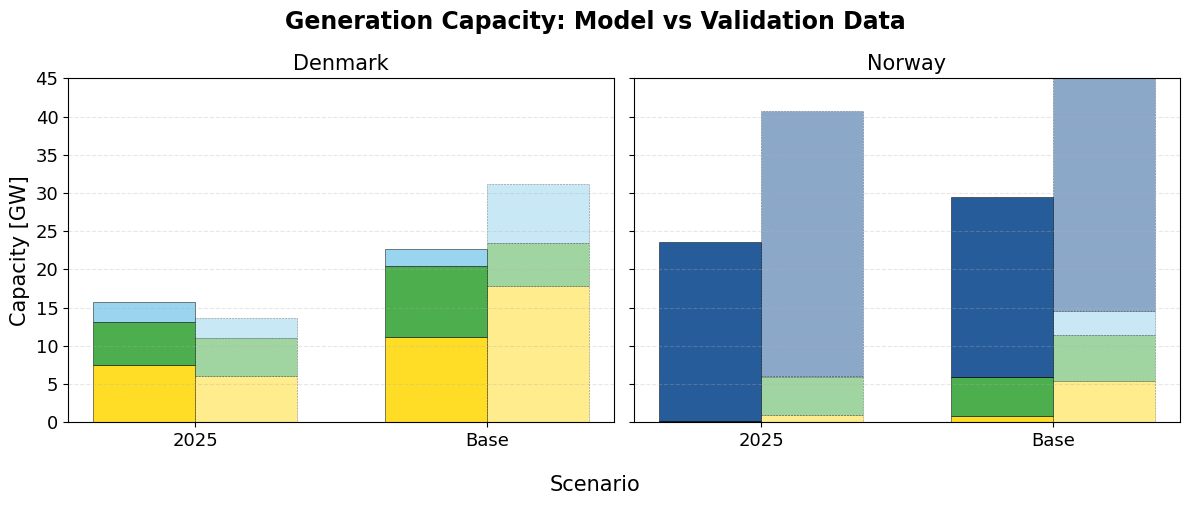

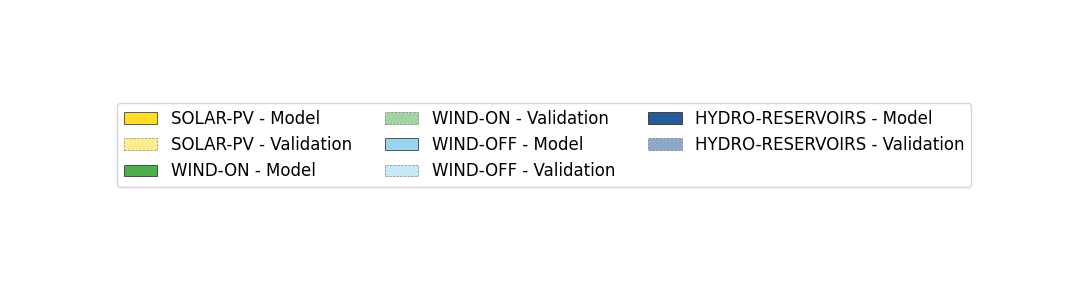

In [38]:
# Fixed common y-axis scale
ymax_fixed = 45


def plot_model_vs_validation(country, scenario_list, ax, ymax_fixed):
    x_pos = np.arange(len(scenario_list))
    bar_width = 0.35

    model_bottom = np.zeros(len(scenario_list))
    val_bottom = np.zeros(len(scenario_list))

    for tech in validation_techs:
        model_vals = []
        val_vals = []

        for scenario in scenario_list:

            # Model values
            model_vals.append(
                model_data[country].loc[scenario, tech]
                if tech in model_data[country].columns
                else 0
            )

            # Validation values
            if scenario == '2025':
                val_key = (country, '2025')
                val_vals.append(
                    validation_data[val_key].get(tech, 0)
                )

            elif scenario == 'Base':
                val_key = (country, '2030')
                val_vals.append(
                    validation_data[val_key].get(tech, 0)
                )

            else:
                val_vals.append(0)

        model_vals = np.array(model_vals)
        val_vals = np.array(val_vals)

        if model_vals.sum() > 0 or val_vals.sum() > 0:

            color = technology_colors.get(tech, '#CCCCCC')

            # Model
            ax.bar(
                x_pos - bar_width / 2,
                model_vals,
                bar_width,
                bottom=model_bottom,
                color=color,
                alpha=0.85,
                edgecolor='black',
                linewidth=0.4
            )

            # Validation
            ax.bar(
                x_pos + bar_width / 2,
                val_vals,
                bar_width,
                bottom=val_bottom,
                color=color,
                alpha=0.45,
                edgecolor='black',
                linewidth=0.4,
                linestyle='--'
            )

            model_bottom += model_vals
            val_bottom += val_vals

    ax.set_title(country.title(), fontsize=15)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        scenario_list,
        fontsize=13
    )

    ax.set_ylim(0, ymax_fixed)
    ax.set_yticks(np.arange(0, ymax_fixed + 5, 5))
    ax.tick_params(axis='y', labelsize=13)

    ax.grid(
        axis='y',
        alpha=0.3,
        linestyle='--'
    )


# ============================================================
# PLOT BOTH COUNTRIES TOGETHER
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharey=True
)

for ax, country in zip(axes, countries):
    plot_model_vs_validation(
        country,
        scenario_order,
        ax,
        ymax_fixed
    )

# Only left panel has y-label
axes[0].set_ylabel(
    'Capacity [GW]',
    fontsize=15
)

axes[1].set_ylabel('')

# Common x-label
fig.supxlabel(
    'Scenario',
    fontsize=15
)

# Common title
fig.suptitle(
    'Generation Capacity: Model vs Validation Data',
    fontsize=17,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# ============================================================
# SHARED LEGEND
# ============================================================

create_combined_legend(
    validation_techs,
    technology_colors
)